In [1]:
import os 
from dotenv import load_dotenv
from langchain_deepseek import ChatDeepSeek

load_dotenv("apikey.env")
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY'] = os.getenv("LANGCHAIN_API_KEY")
os.environ['LANGCHAIN_PROJECT'] = "LangGraph quick start"
BASE_URL = 'https://api.deepseek.com'
API_KEY = os.getenv('DEEPSEEK-API-KEY')

# 1. Install dependencies

`pip install -U langgraph `

# 2. Create an agent

To create an agent, use [`create_react_agent`](https://langchain-ai.github.io/langgraph/reference/agents/):

In [4]:
from langgraph.prebuilt import create_react_agent

def get_weather(city: str) -> str:  
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"


model = ChatDeepSeek(base_url=BASE_URL, 
                     api_key=API_KEY, 
                     model="deepseek-chat",
                     temperature=0.0)

agent = create_react_agent(
    model= model,  
    tools=[get_weather],  
    prompt="You are a helpful assistant"  
)

# Run the agent
for event in agent.stream(
    {"messages": [{"role": "user", "content": "今天海南的天气如何？"}]}):
    for value in event.values():
            print("Assistant:", value["messages"][-1].content)


Assistant: 我来帮您查询海南的天气情况。
Assistant: It's always sunny in 海南!
Assistant: 根据查询结果，海南今天的天气是晴朗的！海南以阳光充足著称，今天也不例外。建议您：

- 做好防晒措施，带上太阳镜和防晒霜
- 穿着轻便透气的衣物
- 多补充水分，避免中暑

如果您需要了解海南具体某个城市的天气情况（比如海口、三亚等），我可以为您查询更详细的信息。


5. Add memory

Only use `InMemorySaver` for debugging or **testing purposes**. For production use cases we recommend installing langgraph-checkpoint-postgres and using `PostgresSaver` / `AsyncPostgresSaver`.

If you are using the LangGraph Platform, no checkpointer needs to be specified. The correct managed checkpointer will be used automatically.

In [9]:
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

agent = create_react_agent(
    model=model,
    tools=[get_weather],
    checkpointer=checkpointer  
)

# Run the agent
config = {"configurable": {"thread_id": "1"}}

shanghai_response ={"messages": [{"role": "user", "content": "今天上海的天气如何？"}]}


ny_response = {"messages": [{"role": "user", "content": "我待会要去上海你有什么建议吗？"}]}

In [10]:
for event in agent.stream(shanghai_response, config):
    for value in event.values():
            print("Assistant:", value["messages"][-1].content)
print("\n=============================================\n")
for event in agent.stream(ny_response, config):
    for value in event.values():
            print("Assistant:", value["messages"][-1].content)

Assistant: 我来帮您查询今天上海的天气情况。
Assistant: It's always sunny in Shanghai!
Assistant: 根据查询结果，今天上海的天气是晴朗的！上海今天阳光明媚，是个好天气。


Assistant: 既然您要去上海，这里有一些建议：

**天气方面：**
- 今天上海天气晴朗，阳光明媚，是个出行的好天气
- 建议带上防晒用品，如太阳镜、防晒霜等
- 穿着轻便舒适的衣物

**出行建议：**
- 上海的公共交通很发达，可以乘坐地铁或公交
- 如果去热门景点，建议提前规划路线
- 下载"Metro大都会"APP方便乘坐地铁

**值得一去的地方：**
- 外滩：欣赏黄浦江两岸的风景
- 南京路步行街：购物和品尝美食
- 豫园：体验传统园林文化
- 陆家嘴：感受现代都市风貌

**其他提醒：**
- 随身携带身份证件
- 注意保管好个人财物
- 可以尝试当地特色小吃

祝您在上海玩得愉快！有什么具体想了解的吗？


# Bulit a basic chatbot


In [11]:
# 1. Create a StateGraph

from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

- Our graph can now handle two key tasks:

    - Each `node` can receive the current `State` as input and output an update to the state.
    - Updates to `messages` will be **appended to the existing list** rather than overwriting it, thanks to the prebuilt reducer function.

In [ ]:
def chatbot(state: State):
    return {"messages": [model.invoke(state["messages"])]}


# The first argument is the **unique node name**
# The second argument is the **function or object** that will be called whenever
# the node is used.
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)
graph = graph_builder.compile()

Add an `entry` point to tell the graph **where to start** its work each time it is run

Add an `exit` point to indicate where the graph should **finish execution**. 

Before running the graph, we'll need to **compile it**. We can do so by calling `compile()` on the graph builder. This creates a CompiledGraph we can invoke on our state.

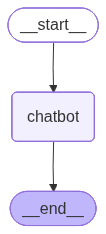

In [14]:
# You can visualize the graph using the get_graph method and one of the "draw" methods
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [17]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

Assistant: 你好！很高兴见到你！😊 有什么我可以帮助你的吗？无论是回答问题、聊天，还是帮你解决什么难题，我都很乐意为你效劳～
Assistant: 你好！我是DeepSeek，由深度求索公司创造的AI助手。😊

我是一个纯文本模型，擅长回答各种问题、协助处理文字工作、进行对话交流等。虽然我不支持多模态识别功能，但我可以帮你处理上传的文件，比如图像、txt、pdf、ppt、word、excel等文件，从中读取文字信息进行分析处理。

我的特点包括：
- 完全免费使用，没有收费计划
- 支持128K上下文长度
- 支持联网搜索（需要手动开启）
- 可以通过官方应用商店下载App使用

我很乐意为你提供帮助！无论是学习、工作还是日常生活中的问题，都可以随时问我。有什么我可以帮你的吗？✨
Assistant: 再见！很高兴能与你交流，如果以后有任何问题或想法，随时欢迎回来聊聊。祝你一切顺利，期待下次相遇！👋✨
Goodbye!


# 支持流式输出

In [21]:
from typing import Annotated
from langchain.chat_models import init_chat_model
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

def chatbot(state: State):
    print("Assistant:", end=" ", flush=True)
    full_text = ""
    for chunk in model.stream(state["messages"]):
        delta = chunk.content
        print(delta, end="", flush=True)
        full_text += delta
    print()  # 换行
    return {"messages": [{"role": "assistant", "content": full_text}]}


graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()


In [22]:
graph.invoke({"messages": [{"role": "user", "content": "介绍一下LangGraph的stream机制"}]})

Assistant: 好的，我们来详细介绍一下 LangGraph 的 Stream 机制。

### 1. 核心概念：什么是 LangGraph 的 Stream？

LangGraph 的 Stream 机制是一种**逐步获取图执行结果**的方式。与一次性调用并等待整个图执行完毕不同，Stream 允许你在图的每个步骤（或状态更新时）**实时地接收到中间结果**。

这类似于观看一场体育比赛的“直播”（Stream）而不是等待比赛结束后的“录播回放”（一次性调用）。直播让你能实时看到每一个进球、每一次攻防转换。

### 2. 为什么需要 Stream 机制？

1.  **实时反馈与用户体验**：
    - 对于需要与用户交互的代理应用，你可以将“思考过程”（如“我正在搜索...”、“我正在分析...”）实时展示给用户，提供更流畅、更透明的体验。
    - 例如，一个聊天机器人可以逐步输出“思考”、“行动”、“观察”、“最终回答”等步骤，而不是让用户长时间等待。

2.  **调试与监控**：
    - 开发者可以清晰地看到图的执行路径、每个节点被调用的顺序、节点的输入输出，这对于调试复杂的工作流至关重要。

3.  **处理长耗时任务**：
    - 如果一个图包含多个耗时节点（如调用外部 API），Stream 可以让你在某个节点完成后就立即获取到部分结果，而不必等待所有节点都完成。

4.  **构建响应式前端**：
    - 前端应用可以订阅 Stream，并在收到新数据时立即更新 UI（例如，逐步显示生成的文本或图表）。

### 3. Stream 的工作模式

LangGraph 提供了几种不同的 Stream 模式，让你可以控制接收到的数据粒度。

#### 主要模式：

1.  **`values` (默认模式)**
    - **功能**：在图的**每次状态更新后**，流式返回整个状态（State）的**当前值**。
    - **特点**：你会看到状态对象随着每个节点的执行而逐步“填充”和演变。这是最常用也是最直观的模式。
    - **适用场景**：大多数需要跟踪完整状态变化的场景。

2.  **`updates`**
    - **功能**：在图的**每次状态更新后**，流式返回**被修改的那部分状态**。
   

{'messages': [HumanMessage(content='介绍一下LangGraph的stream机制', additional_kwargs={}, response_metadata={}, id='b7f53cd8-8633-48f5-801c-40366481eb0c'),
  AIMessage(content='好的，我们来详细介绍一下 LangGraph 的 Stream 机制。\n\n### 1. 核心概念：什么是 LangGraph 的 Stream？\n\nLangGraph 的 Stream 机制是一种**逐步获取图执行结果**的方式。与一次性调用并等待整个图执行完毕不同，Stream 允许你在图的每个步骤（或状态更新时）**实时地接收到中间结果**。\n\n这类似于观看一场体育比赛的“直播”（Stream）而不是等待比赛结束后的“录播回放”（一次性调用）。直播让你能实时看到每一个进球、每一次攻防转换。\n\n### 2. 为什么需要 Stream 机制？\n\n1.  **实时反馈与用户体验**：\n    - 对于需要与用户交互的代理应用，你可以将“思考过程”（如“我正在搜索...”、“我正在分析...”）实时展示给用户，提供更流畅、更透明的体验。\n    - 例如，一个聊天机器人可以逐步输出“思考”、“行动”、“观察”、“最终回答”等步骤，而不是让用户长时间等待。\n\n2.  **调试与监控**：\n    - 开发者可以清晰地看到图的执行路径、每个节点被调用的顺序、节点的输入输出，这对于调试复杂的工作流至关重要。\n\n3.  **处理长耗时任务**：\n    - 如果一个图包含多个耗时节点（如调用外部 API），Stream 可以让你在某个节点完成后就立即获取到部分结果，而不必等待所有节点都完成。\n\n4.  **构建响应式前端**：\n    - 前端应用可以订阅 Stream，并在收到新数据时立即更新 UI（例如，逐步显示生成的文本或图表）。\n\n### 3. Stream 的工作模式\n\nLangGraph 提供了几种不同的 Stream 模式，让你可以控制接收到的数据粒度。\n\n#### 主要模式：\n\n1.  **`values` (默认模式)**\n    - **功能**：在图的**每次状态